In [1]:
import gc
import os
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # suppress CUDA errors
import tensorflow as tf
from keras import mixed_precision, utils, saving, layers, losses, optimizers, metrics, callbacks, Sequential
from sklearn import model_selection

mixed_precision.set_global_policy('mixed_float16') # https://keras.io/2/api/mixed_precision/policy/
utils.set_random_seed(42)

In [2]:
data = pl.read_csv('train.csv').drop('date_id').with_columns(
    pl.all().cast(pl.Float64, strict=False),
    pl.col('forward_returns').shift(-1).alias('lagged_forward_returns'),
    pl.col('risk_free_rate').shift(-1).alias('lagged_risk_free_rate'),
    pl.col('market_forward_excess_returns').shift(-1).alias('lagged_market_forward_excess_returns'),
).fill_null(0.0)
data

D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,I8,…,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns,lagged_forward_returns,lagged_risk_free_rate,lagged_market_forward_excess_returns
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.002421,0.000301,-0.003038,-0.008495,0.000303,-0.009114
0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.008495,0.000303,-0.009114,-0.009624,0.000301,-0.010243
0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.009624,0.000301,-0.010243,0.004662,0.000299,0.004046
0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.004662,0.000299,0.004046,-0.011686,0.000299,-0.012301
0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.011686,0.000299,-0.012301,-0.006449,0.0003,-0.007066
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.565379,0.184524,0.01918,0.01918,0.005952,0.005952,0.911376,-0.083496,-0.572447,0.223638,-0.122314,1.20925,1.540116,1.655174,0.031415,0.33168,0.034722,0.038269,-0.301876,0.914683,0.27414,0.984115,0.080688,0.476521,0.597442,0.718254,0.238757,0.351852,…,0.51455,0.276769,-0.261326,0.811754,1.784929,0.039683,0.249933,0.273148,0.134921,0.634465,-0.446682,-0.052686,0.083995,0.055282,0.209656,0.409392,0.574661,0.748677,0.498677,-0.616395,0.561839,0.53373,-0.432282,0.785053,0.469577,0.837963,1.226772,0.822751,-0.707361,0.142857,-0.649616,0.002457,0.000155,0.00199,0.002312,0.000156,0.001845
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.562946,0.184193,0.018849,0.018849,0.005622,0.005622,0.911706,-0.083542,-0.57208,0.22291,-0.732397,1.225459,1.537761,1.672262,0.031085,0.331349,0.034392,0.038205,-0.301897,0.915013,0.269841,0.904453,0.073413,0.479167,0.605079,0.718254,0.220899,0.345238,…,0.379299,1.19926,-0.344274,0.690323,1.791596,0.037037,0.298533,0.933201,0.721561,1.211345,-0.11805,-0.249315,0.566799,0.10733,0.228175,0.409392,0.580932,0.37037,0.528439,-0.64204,0.587632,0.526455,-0.429506,0.767857,0.671958,0.837963,0.785877,0.805556,-0.715692,0.196098,-0.668289,0.002312,0.000156,0.001845,0.002891,0.000156,0.002424
0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.56052,0.183862,0.018519,0.018519,0.005291,0.005291,0.912037,-0.083874,-0.572016,0.222211,-0.800465,1.247273,1.534742,1.695469,0.030754,0.331019,0.034061,0.038118,-0.301918,0.915344,0.273148,0.842295,0.074074,0.478836,0.611319,0.724868,0.223

In [3]:
MAX_SIGNAL = 1.0
MIN_SIGNAL = 0.0
MID_SIGNAL = (MAX_SIGNAL + MIN_SIGNAL) / 2

In [4]:
inputs = data.with_columns(
    pl.when(pl.col('forward_returns') > pl.col('risk_free_rate')).then(MAX_SIGNAL).otherwise(MIN_SIGNAL).alias('target')
).drop(['forward_returns', 'risk_free_rate', 'market_forward_excess_returns']).to_numpy()
inputs.shape

(8990, 98)

In [5]:
def hull_composite_loss(y_true, y_pred):
    penalties = [
        losses.binary_crossentropy(y_true, y_pred, from_logits=True, label_smoothing=0.3),
        tf.reduce_mean(tf.maximum(0.0, y_pred - y_true)), # punishes false positives
        tf.reduce_mean(tf.maximum(0.0, y_true - y_pred)), # punishes false negatives
        tf.reduce_mean(tf.square(tf.maximum(0.0, MIN_SIGNAL - y_pred))), # punishes values below min signal
        tf.reduce_mean(tf.square(tf.maximum(0.0, y_pred - MAX_SIGNAL))), # punishes values above max signal
        tf.reduce_mean(tf.square(1.0 / (tf.abs(y_pred - MID_SIGNAL) + 1e7))), # punishes indecision (predictions halfway between min and max signal)
        1.0 / (tf.math.reduce_variance(y_pred) + 1e7), # punishes guessing constant or near-constant values
        1.0 / (tf.math.reduce_std(y_pred) + 1e7), # also punishes guessing constant or near-constant values
    ]
    return sum(penalties)

In [6]:
def create_sequences(inputs:np.ndarray, seq_length:int, step_size:int=1):
    n_samples, n_features = inputs.shape
    n_sequences = (n_samples - seq_length - step_size)
    X = np.empty((n_sequences, seq_length, n_features))
    y = np.empty(n_sequences)
    for i in range(n_sequences):
        start_idx = i * step_size
        X[i] = inputs[start_idx:start_idx+seq_length, :]
        y[i] = inputs[start_idx+seq_length, -1]
    return X, y

In [7]:
MODEL_NAME = 'v83'
MAX_EPOCHS = 20000
MIN_EPOCHS =  1000
N_FEATURES = inputs.shape[-1]
SEQ_LENGTH = 3

X, y = create_sequences(inputs, SEQ_LENGTH)

model = None

# ensure previously trained models aren't overwritten
for file in os.listdir('.models/'):
    if file.startswith(MODEL_NAME):
        model = saving.load_model(f'.models/{file}', compile=False)

if model is None:
    model = Sequential([
        layers.Dropout(0.1),
        layers.BatchNormalization(),
        layers.LSTM(N_FEATURES * SEQ_LENGTH),
        layers.Dropout(0.1),
        layers.BatchNormalization(),
        layers.Dense(N_FEATURES),
        layers.Dropout(0.1),
        layers.BatchNormalization(),
        layers.Dense(int(2 * N_FEATURES // 3)),
        layers.Dropout(0.1),
        layers.BatchNormalization(),
        layers.Dense(int(2 * N_FEATURES // 3)),
        layers.Dropout(0.1),
        layers.BatchNormalization(),
        layers.Dense(int(4 * N_FEATURES // 9)),
        layers.Dropout(0.1),
        layers.BatchNormalization(),
        layers.Dense(int(4 * N_FEATURES // 9)),
        layers.Dropout(0.1),
        layers.BatchNormalization(),
        layers.Dense(int(16 * N_FEATURES // 81)),
        layers.Dropout(0.1),
        layers.BatchNormalization(),
        layers.Dense(int(16 * N_FEATURES // 81)),
        layers.Dropout(0.1),
        layers.BatchNormalization(),
        layers.Dense(1, activation='sigmoid')
    ], name=MODEL_NAME)
    model.compile(loss=hull_composite_loss, optimizer=optimizers.Adamax(), metrics=[metrics.MeanAbsoluteError()])
    for k, (i_train, i_val) in enumerate(model_selection.TimeSeriesSplit().split(X)):
        model.fit(X[i_train, :], y[i_train], epochs=MAX_EPOCHS, validation_data=(X[i_val, :], y[i_val]), verbose=0,
                  callbacks=[callbacks.EarlyStopping(patience=MIN_EPOCHS, restore_best_weights=True), callbacks.TerminateOnNaN()])
        model.save(f'.models/{model.name}.keras')
        while gc.collect() > 0: pass

I0000 00:00:1761390081.222490   13990 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9413 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1761390081.223980   13990 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 4519 MB memory:  -> device: 1, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:06:00.0, compute capability: 7.5


In [8]:
test_data = pl.read_csv('test.csv').drop(['date_id', 'is_scored']).with_columns(
    pl.when(pl.col('lagged_forward_returns').shift(1) > pl.col('lagged_risk_free_rate').shift(1))
      .then(MAX_SIGNAL).otherwise(MIN_SIGNAL).alias('target')
)
test_data.shape

(10, 98)

In [9]:
X_test, y_test = create_sequences(test_data.to_numpy(), 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


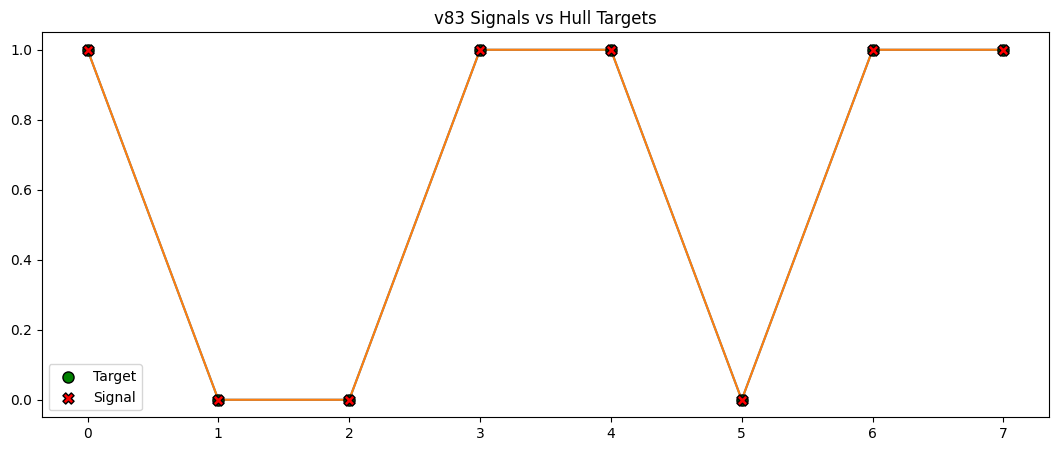

In [10]:
plt.figure(figsize=(13, 5))
plt.title(f'{model.name} Signals vs Hull Targets')
plt.plot(y_test, zorder=-1)
indices = np.arange(y_test.shape[0])
plt.scatter(indices, y_test, label='Target', edgecolors='k', c='g', s=64)
predictions = model.predict(X_test).flatten()
plt.plot(predictions, zorder=-1)
plt.scatter(indices, predictions[-indices.shape[0]:], label='Signal', marker='X', edgecolors='k', c='r', s=64)
plt.legend()
pass

In [11]:
MIN_INVESTMENT = 0
MAX_INVESTMENT = 2

def score(solution: pl.DataFrame, submission: pl.DataFrame) -> float:
    """
    Calculates a custom evaluation metric (volatility-adjusted Sharpe ratio).

    This metric penalizes strategies that take on significantly more volatility
    than the underlying market.

    Returns:
        float: The calculated adjusted Sharpe ratio.
    """

    if not submission['prediction'].dtype.is_numeric(): raise Exception('Predictions must be numeric')

    solution = solution.with_columns(position=submission['prediction'])

    pos_max = solution.select(pl.col('position').max()).item()
    if pos_max > MAX_INVESTMENT: raise Exception(f'Position of {pos_max} exceeds maximum of {MAX_INVESTMENT}')

    pos_min = solution.select(pl.col('position').min()).item()
    if pos_min < MIN_INVESTMENT: raise Exception(f'Position of {pos_min} below minimum of {MIN_INVESTMENT}')

    solution = solution.with_columns(strategy_returns=pl.col('risk_free_rate') * (1 - pl.col('position')) + pl.col('position') * pl.col('forward_returns'))

    n = len(solution)
    trading_days_per_yr = 252

    # Calculate strategy's Sharpe ratio
    strategy_excess_cumulative = solution.select((1 + (pl.col('strategy_returns') - pl.col('risk_free_rate'))).product()).item()
    strategy_mean_excess_return = (strategy_excess_cumulative) ** (1 / n) - 1
    strategy_std = solution.select(pl.col('strategy_returns').std()).item()
    if strategy_std == 0: raise Exception('Division by zero, strategy std is zero')
    sharpe = strategy_mean_excess_return / strategy_std * np.sqrt(trading_days_per_yr)
    strategy_volatility = float(strategy_std * np.sqrt(trading_days_per_yr) * 100)

    # Calculate market return and volatility
    market_excess_cumulative = solution.select((1 + (pl.col('forward_returns') - pl.col('risk_free_rate'))).product()).item()
    market_mean_excess_return = (market_excess_cumulative) ** (1 / n) - 1
    market_std = solution.select(pl.col('forward_returns').std()).item()
    market_volatility = float(market_std * np.sqrt(trading_days_per_yr) * 100)
    if market_volatility == 0: raise Exception('Division by zero, market std is zero')

    # Calculate the volatility penalty
    excess_vol = max(0, strategy_volatility / market_volatility - 1.2) if market_volatility > 0 else 0
    vol_penalty = 1 + excess_vol

    # Calculate the return penalty
    return_gap = max(0, (market_mean_excess_return - strategy_mean_excess_return) * 100 * trading_days_per_yr)
    return_penalty = 1 + (return_gap**2) / 100

    # Adjust the Sharpe ratio by the volatility and return penalty
    adjusted_sharpe = sharpe / (vol_penalty * return_penalty)
    return min(float(adjusted_sharpe), 1_000_000)

In [12]:
test_solution = test_data.with_columns(
    forward_returns=pl.col('lagged_forward_returns').shift(1),
    risk_free_rate=pl.col('lagged_risk_free_rate').shift(1),
    market_forward_excess_returns=pl.col('lagged_market_forward_excess_returns').shift(1),
).drop(['lagged_forward_returns','lagged_risk_free_rate','lagged_market_forward_excess_returns']).fill_null(0)
test_solution

D1,D2,D3,D4,D5,D6,D7,D8,D9,E1,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E2,E20,E3,E4,E5,E6,E7,E8,E9,I1,I2,I3,I4,I5,I6,I7,I8,…,P2,P3,P4,P5,P6,P7,P8,P9,S1,S10,S11,S12,S2,S3,S4,S5,S6,S7,S8,S9,V1,V10,V11,V12,V13,V2,V3,V4,V5,V6,V7,V8,V9,target,forward_returns,risk_free_rate,market_forward_excess_returns
i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0,0,0,1,0,0,1,0,1.577651,0.186177,0.001323,0.001323,0.001323,0.001323,0.955026,-0.583419,-0.704264,0.298365,-0.691361,1.259065,1.556516,1.71258,0.033069,0.333333,0.036376,-0.046483,-0.312326,0.913029,0.306217,1.025756,0.081349,0.478175,0.675627,0.699735,0.256283,0.36045,…,-1.427834,0.352513,0.926257,0.431383,-0.476976,0.500245,1.784173,0.029762,0.294719,0.51455,0.446429,0.466551,0.085717,-0.230132,0.272487,-0.106894,0.199735,0.409392,0.532717,0.744048,0.440476,-0.654839,0.699735,0.699074,-0.5024,0.882937,0.892196,0.828042,0.999172,0.759921,-0.803127,0.170966,-0.751909,0.0,0.0,0.0,0.0
0,0,0,0,1,0,0,1,0,1.575182,0.185847,0.000992,0.000992,0.000992,0.000992,0.955357,-0.583074,-0.703759,0.297608,-0.504499,1.193468,1.554184,1.640054,0.032738,0.333003,0.036045,0.073582,-0.312345,0.91336,0.305886,0.989571,0.082672,0.477844,0.661527,0.719577,0.255952,0.361111,…,-1.37652,0.953042,0.386905,0.523549,-0.421365,-0.234829,1.770175,0.03373,0.304496,0.638228,0.636905,1.849101,0.28169,-0.041995,0.448413,0.094321,0.215608,0.409392,0.597864,0.872354,0.691138,-0.583443,0.62996,0.598545,-0.394268,0.863757,0.699074,0.831349,1.120336,0.556217,-0.686192,0.141865,-0.660326,1.0,0.003541,0.000161,0.003068
0,0,0,0,1,0,0,0,1,1.57272,0.185516,0.000661,0.000661,0.000661,0.000661,0.955688,-0.083356,-0.573546,0.225822,-0.393903,1.123361,1.551723,1.562722,0.032407,0.332672,0.035714,0.033581,-0.312364,0.91369,0.291997,1.040514,0.081349,0.477513,0.655741,0.724206,0.22619,0.35582,…,-1.34762,0.210979,0.635251,-1.138198,-0.494248,-1.042718,1.754171,0.032407,0.257609,0.082011,0.152116,-0.201611,0.346373,0.054032,0.137566,0.294305,0.194444,0.409392,0.596528,0.778439,0.634921,-0.483236,0.669974,0.603836,-0.17042,0.848545,0.647487,0.832672,1.088992,0.665344,-0.459367,0.199405,-0.510979,0.0,-0.005964,0.000162,-0.006437
0,0,0,0,1,0,0,0,1,1.570266,0.185185,0.019841,0.019841,0.006614,0.006614,0.956019,-0.083403,-0.57318,0.225094,-0.541646,1.167982,1.549272,1.611215,0.032077,0.332341,0.035384,0.033998,-0.312383,0.914021,0.267196,1.091376,0.085979,0.477183,0.648582,0.728175,0.230159,0.351852,…,-1.399411,0.724868,0.21627,-0.230557,-0.318347,0.396917,1.769678,0.03373,0.20235,0.324074,0.212963,0.052878,-0.049023,0.120828,0.219577,0.137942,0.167328,0.409392,0.579726,0.449735,0.665344,-0.546298,0.590608,0.558862,-0.275099,0.826058,0.445767,0.835979,1.040988,0.594577,-0.561643,0.161706,-0.575997,0.0,-0.00741,0.00016,-0.007882
0,0,0,0,0,0,1,0,1,1.567818,0.184854,0.019511,0.019511,0.006283,0.006283,0.956349,-0.083449,-0.572813,0.224366,-0.714549,1.243713,1.542543,1.693604,0.031746,0.332011,0.035053,0.029586,-0.301855,0.914352,0.260913,1.011571,0.093915,0.476852,0.638667,0.729497,0.238757,0.353836,…,-1.416282,0.611442,0.426257,0.046472,-0.262086,1.304142,1.785515,0.039683,0.230364,0.583995,0.445106,1.378927,-0.182025,0.01261,0.369048,0.011021,0.130291,0.409392,0.572656,0.489418,0.600529,-0.587258,0.46131,0.487434,-0.39548,0.80754,0.707672,0.839947,0.944593,0.715608,-0.692649,0.124669,-0.654045,1.0,0.00542,0.00016,0.004949
0,0,0,0,0,0,0,0,0,1.565379,0.184524,0.01918,0.01918,0.005952,0.005952,0.911376,-0.083496,-0.572447,0.223638,-0.122314,1.20925,1.540116,1.655174,0.031415,0.33168,0.034722,0.038269,-0.301876,0.914683,0.27414,0.984115,0.080688,0.476521,0.597442,0.718254,0.238757,0.351852,…,-1.354498,0.046296,0.51455,0.276769,-0.261326,0.811754,1.784929,0.039683,0.249933,0.273148,0.134921,0.634465,-0

In [13]:
signals = np.where(predictions > 0, MAX_INVESTMENT, MIN_INVESTMENT)
test_submission = pl.DataFrame(signals, schema=['prediction'])
test_submission

prediction
i64
2
0
0
2
2
0
2
2


In [14]:
score(test_solution.slice(-test_submission.shape[0]), test_submission)

1.3479157626061153